In [351]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [352]:
df1=pd.read_csv("btc_5years_binance.csv")
df2=pd.read_csv("eth_5years_binance.csv")

In [353]:
df1.head()

,date,open,high,low,close,volume,quote_volume
0,2020-03-22,6187.04,6407.87,5734.01,5816.19,119115.990527,7.228957e+08
1,2020-03-23,5816.05,6600.00,5688.00,6467.31,164674.215785,1.015526e+09
2,2020-03-24,6465.25,6833.00,6371.33,6744.72,151138.009878,1.001891e+09
3,2020-03-25,6744.69,6957.96,6450.00,6677.43,132155.734989,8.802507e+08
4,2020-03-26,6677.42,6780.00,6510.00,6737.36,83026.555211,5.525372e+08


In [354]:
df2.head()

,date,open,high,low,close,volume,quote_volume
0,2020-03-22,132.63,137.13,121.10,122.32,1.055700e+06,1.359279e+08
1,2020-03-23,122.31,137.50,119.50,135.92,1.436796e+06,1.848516e+08
2,2020-03-24,135.89,143.36,132.20,138.42,1.244377e+06,1.711564e+08
3,2020-03-25,138.42,142.33,132.54,136.10,1.034249e+06,1.417953e+08
4,2020-03-26,136.11,139.74,133.26,138.40,7.510606e+05,1.019188e+08


In [355]:
df1["date"].value_counts()

date
2020-03-22    1
2020-03-23    1
2020-03-24    1
2020-03-25    1
2020-03-26    1
             ..
2026-03-16    1
2026-03-17    1
2026-03-18    1
2026-03-19    1
2026-03-20    1
Name: count, Length: 2190, dtype: int64

In [356]:
df1["date"]=pd.to_datetime(df1['date'])
df1["year"]=df1['date'].dt.year

In [357]:
df1['year'].value_counts()

year
2024    366
2022    365
2021    365
2025    365
2023    365
2020    285
2026     79
Name: count, dtype: int64

In [358]:
df1=df1.drop(columns="year")

In [359]:
df1.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'quote_volume'], dtype='object')

In [360]:
df1.isna().sum()

date            0
open            0
high            0
low             0
close           0
volume          0
quote_volume    0
dtype: int64

In [361]:
df1.duplicated(subset='date').sum()

np.int64(0)

In [362]:
df2['date']=pd.to_datetime(df2['date'])

In [363]:
df2.duplicated(subset='date').sum()

np.int64(0)

In [364]:
df1["type"]='BTC'

In [365]:
df1.head()

,date,open,high,low,close,volume,quote_volume,type
0,2020-03-22,6187.04,6407.87,5734.01,5816.19,119115.990527,7.228957e+08,BTC
1,2020-03-23,5816.05,6600.00,5688.00,6467.31,164674.215785,1.015526e+09,BTC
2,2020-03-24,6465.25,6833.00,6371.33,6744.72,151138.009878,1.001891e+09,BTC
3,2020-03-25,6744.69,6957.96,6450.00,6677.43,132155.734989,8.802507e+08,BTC
4,2020-03-26,6677.42,6780.00,6510.00,6737.36,83026.555211,5.525372e+08,BTC


In [366]:
df2["type"]='ETH'

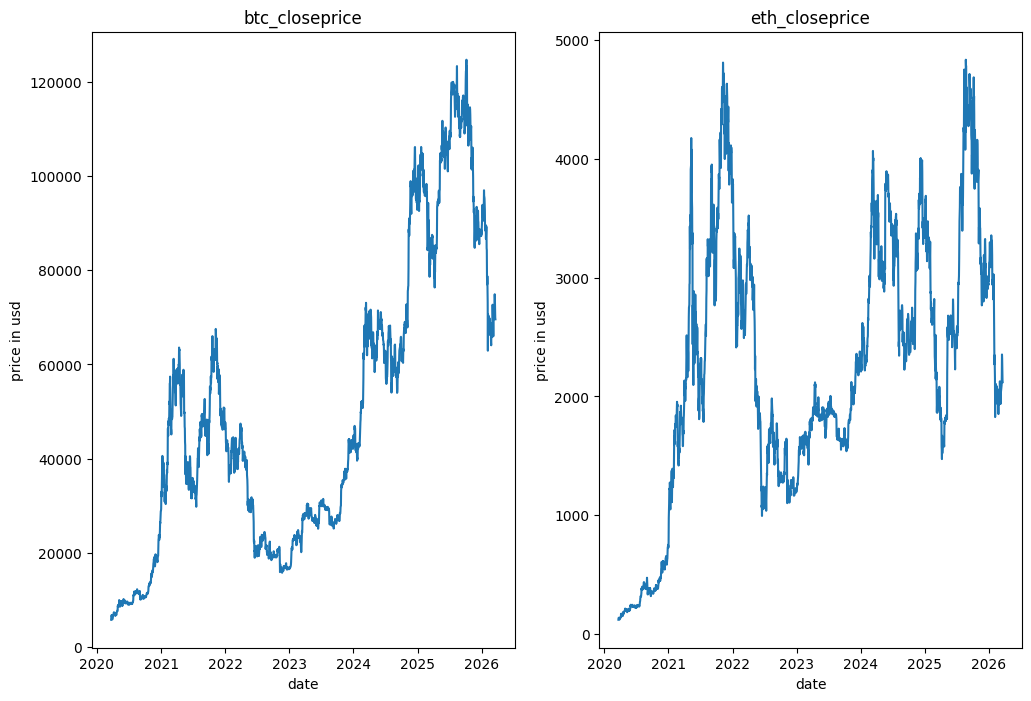

In [367]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.lineplot(x='date',data=df1,y='close')
plt.title("btc_closeprice")
plt.ylabel("price in usd")
plt.subplot(1,2,2)
sns.lineplot(x='date',data=df2,y='close')
plt.title("eth_closeprice")
plt.ylabel("price in usd")
plt.show()

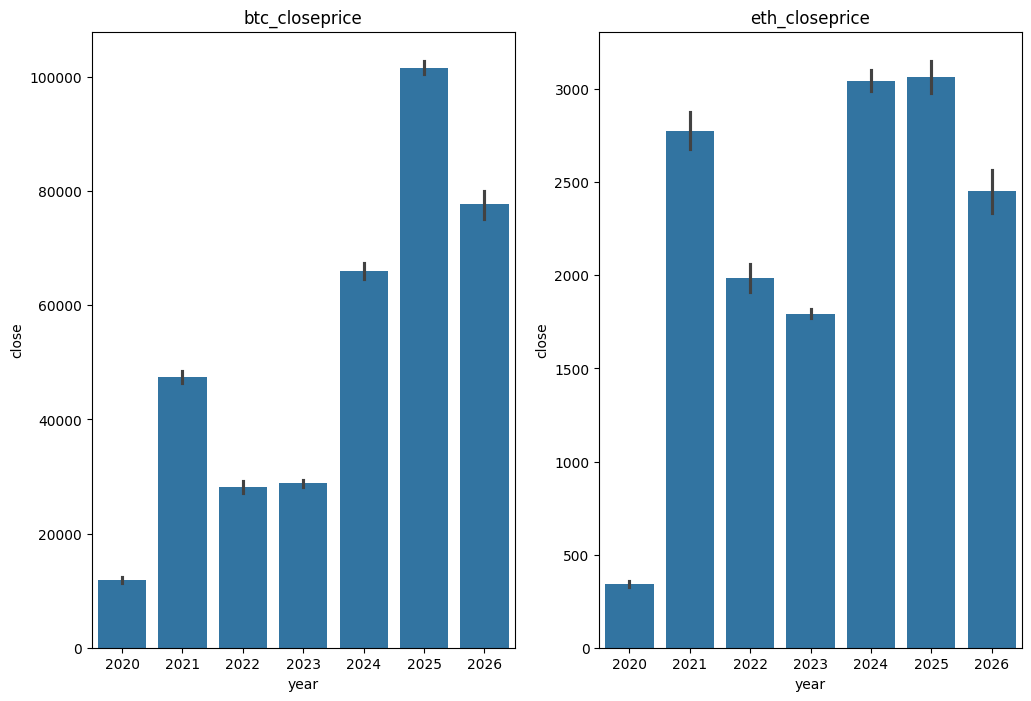

In [368]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
df1["year"]=df1["date"].dt.year
sns.barplot(x='year',data=df1,y='close')
plt.title("btc_closeprice")
plt.subplot(1,2,2)
df2["year"]=df2["date"].dt.year
sns.barplot(x='year',data=df2,y='close')
plt.title("eth_closeprice")
plt.show()

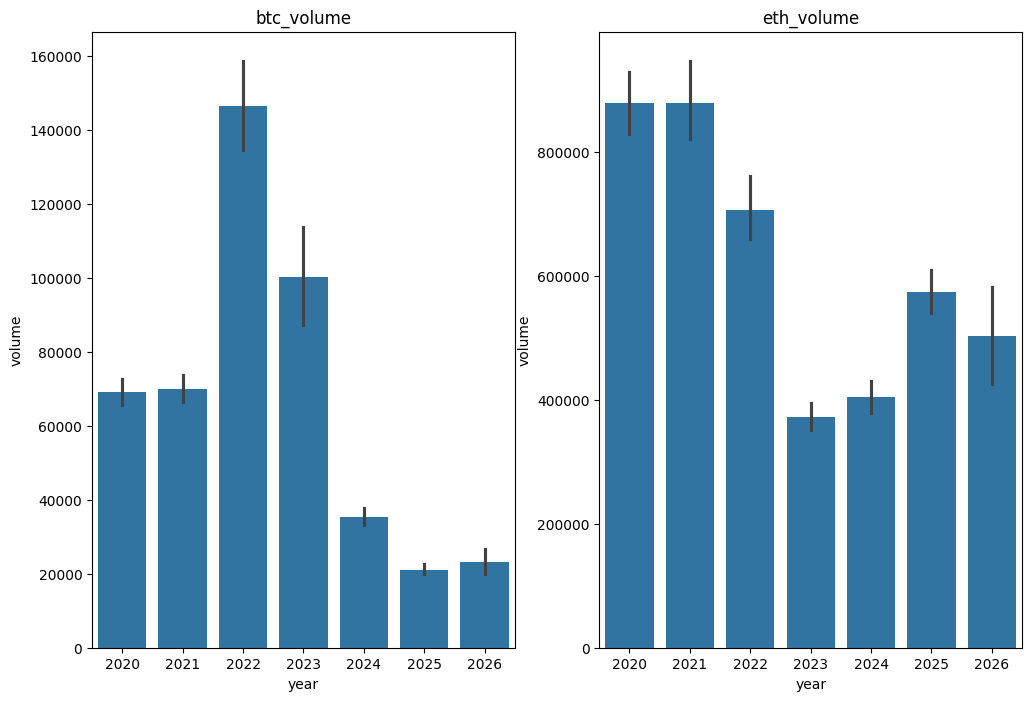

In [369]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
df1["year"]=df1["date"].dt.year
sns.barplot(x='year',data=df1,y='volume')
plt.title("btc_volume")
plt.subplot(1,2,2)
df2["year"]=df2["date"].dt.year
sns.barplot(x='year',data=df2,y='volume')
plt.title("eth_volume")
plt.show()

In [370]:
df1[['open','high','low','close','volume','quote_volume']].describe()

,open,high,low,close,volume,quote_volume
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2.190000e+03
mean,49684.851571,50706.157904,48588.060530,49713.850781,72041.067983,2.405291e+09
std,31059.051366,31510.559634,30557.274821,31048.027839,86914.767449,1.970179e+09
min,5816.050000,6266.000000,5688.000000,5816.190000,3104.117220,2.066281e+08
25%,24342.577500,25132.772500,23863.335000,24413.105000,24744.679520,1.091421e+09
50%,42547.145000,43405.365000,41629.205000,42561.935000,43615.005305,1.873282e+09
75%,67807.182500,68989.000000,66366.835000,67835.537500,77545.003452,3.023708e+09
max,124658.540000,126199.630000,123084.000000,124658.540000,760705.362783,1.746531e+10


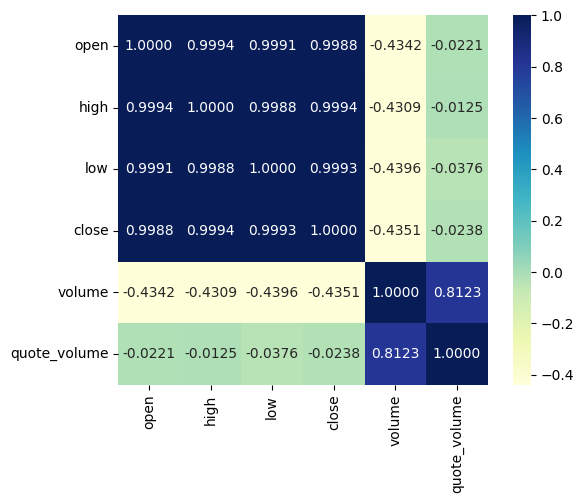

In [371]:
corr1=df1[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr1,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show() #as i predicted above the relation between volume and close price is negative as when volume is high thats mean closing price was low so alot of people buy 

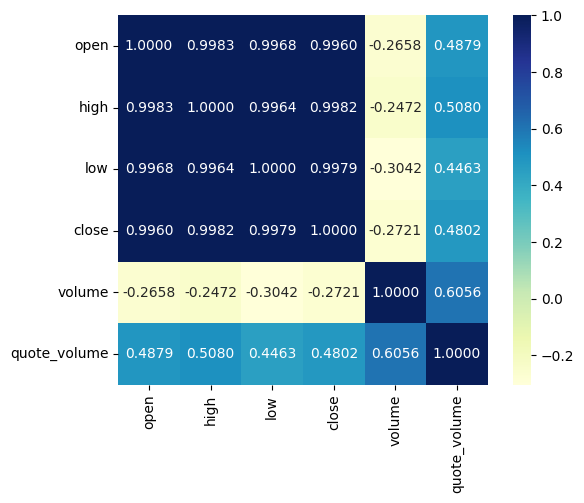

In [372]:
corr2=df2[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr2,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

In [373]:
for year in [2020, 2021, 2022, 2023, 2024,2025]:
    btc_year = df1[df1['date'].dt.year == year]
    
    fig = go.Figure(data=[go.Candlestick(
        x=btc_year['date'],
        open=btc_year['open'],
        high=btc_year['high'],
        low=btc_year['low'],
        close=btc_year['close']
    )])
    
    fig.update_layout(title=f'BTC Candlestick Chart - {year}')
    fig.show()

In [374]:
import plotly.graph_objects as go

years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
}
for year, months in years_months.items():
    btc_filtered = df1[(df1['date'].dt.year == year) & (df1['date'].dt.month.isin(months))]
    
    fig = go.Figure(data=[go.Candlestick(
        x=btc_filtered['date'],
        open=btc_filtered['open'],
        high=btc_filtered['high'],
        low=btc_filtered['low'],
        close=btc_filtered['close']
    )])
    
    fig.update_layout(title=f'BTC Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()

In [375]:
for year in [2020, 2021, 2022, 2023, 2024,2025]:
    eth_year = df2[df2['date'].dt.year == year]
    
    fig = go.Figure(data=[go.Candlestick(
        x=eth_year['date'],
        open=eth_year['open'],
        high=eth_year['high'],
        low=eth_year['low'],
        close=eth_year['close']
    )])
    
    fig.update_layout(title=f'ETH Candlestick Chart - {year}')
    fig.show()

In [376]:
import plotly.graph_objects as go

years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
}
for year, months in years_months.items():
    eth_filtered = df2[(df2['date'].dt.year == year) & (df2['date'].dt.month.isin(months))]
    
    fig = go.Figure(data=[go.Candlestick(
        x=eth_filtered['date'],
        open=eth_filtered['open'],
        high=eth_filtered['high'],
        low=eth_filtered['low'],
        close=eth_filtered['close']
    )])
    
    fig.update_layout(title=f'ETH Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()

In [377]:
df1.drop(columns='year',inplace=True)
df2.drop(columns='year',inplace=True)

## Feature engeering

In [378]:
df1["candle_body"]=df1['close']-df1['open']
df2['candle_body']=df2['close']-df2['open']


In [379]:
df1.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body
0,2020-03-22,6187.04,6407.87,5734.01,5816.19,119115.990527,7.228957e+08,BTC,-370.85
1,2020-03-23,5816.05,6600.00,5688.00,6467.31,164674.215785,1.015526e+09,BTC,651.26
2,2020-03-24,6465.25,6833.00,6371.33,6744.72,151138.009878,1.001891e+09,BTC,279.47
3,2020-03-25,6744.69,6957.96,6450.00,6677.43,132155.734989,8.802507e+08,BTC,-67.26
4,2020-03-26,6677.42,6780.00,6510.00,6737.36,83026.555211,5.525372e+08,BTC,59.94


In [380]:
df1['high_low_range']=df1['high']-df1['low']
df2['high_low_range']=df2['high']-df2['low']

In [381]:
df1['MA_7']=df1['close'].rolling(window=7).mean()
df2['MA_7']=df2['close'].rolling(window=7).mean()

In [382]:
df1['MA_30']=df1['close'].rolling(window=30).mean()
df2['MA_30']=df2['close'].rolling(window=30).mean()

In [383]:
df1['moving_1d']=(df1['close']-df1['close'].shift(1))/df1['close'].shift(1) * 100
df2['moving_1d']=(df2['close']-df2['close'].shift(1))/df2['close'].shift(1) * 100

In [384]:
df1["volatility_7"] = df1["moving_1d"].rolling(window=7).std()
df2["volatility_7"] = df2["moving_1d"].rolling(window=7).std()

In [385]:
df1["volume_MA7"] = df1["volume"].rolling(window=7).mean()
df1["volumelast7"] = df1["volume"] / df1["volume_MA7"]
df2["volume_MA7"] = df2["volume"].rolling(window=7).mean()
df2["volumelast7"] = df2["volume"] / df2["volume_MA7"]

In [386]:
df1.drop(columns='volume_MA7',inplace=True)
df2.drop(columns='volume_MA7',inplace=True)

In [387]:
df1["rolling_mean_30"] = df1["close"].rolling(window=30).mean()
df1["rolling_std_30"]  = df1["close"].rolling(window=30).std()
df1["z_score"] = (df1["close"] - df1["rolling_mean_30"]) / df1["rolling_std_30"]

df2["rolling_mean_30"] = df2["close"].rolling(window=30).mean()
df2["rolling_std_30"]  = df2["close"].rolling(window=30).std()
df2["z_score"] = (df2["close"] - df2["rolling_mean_30"]) / df2["rolling_std_30"]

In [388]:
df1.drop(columns='rolling_mean_30',inplace=True)
df2.drop(columns='rolling_mean_30',inplace=True)
df1.drop(columns='rolling_std_30',inplace=True)
df2.drop(columns='rolling_std_30',inplace=True)

In [389]:
df1['tomorrow_close'] = df1['close'].shift(-1)
df1['tomorrow_return'] = (df1['tomorrow_close'] - df1['close']) / df1['close'] * 100


df2['tomorrow_close'] = df2['close'].shift(-1)
df2['tomorrow_return'] = (df2['tomorrow_close'] - df2['close']) / df2['close'] * 100

In [390]:
def label(x):
    if x > 3:
        return "Bigup"
    elif x < -3 :
        return "Bigdown"
    
    elif x >= -3 and x<=3 :
        return "Stable"
    else:
        return None
    


df1["target"]=df1['tomorrow_return'].apply(label)
df2["target"]=df2['tomorrow_return'].apply(label)

In [391]:
df1.drop(columns='tomorrow_close',inplace=True)
df1.drop(columns='tomorrow_return',inplace=True)
df2.drop(columns='tomorrow_close',inplace=True)
df2.drop(columns='tomorrow_return',inplace=True)

In [393]:
df1[30:35]

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,target
30,2020-04-21,6828.98,6940.00,6762.00,6841.37,60109.710808,4.118006e+08,BTC,12.39,178.00,6969.752857,6800.538667,0.212983,4.018091,0.865563,0.120445,Bigup
31,2020-04-22,6841.36,7156.38,6818.00,7125.14,61486.377334,4.312716e+08,BTC,283.78,338.38,7041.738571,6822.466333,4.147853,3.923088,0.885542,0.895536,Bigup
32,2020-04-23,7125.12,7738.00,7020.00,7482.39,102773.569561,7.563202e+08,BTC,357.27,718.00,7096.088571,6847.055333,5.013937,3.393093,1.551135,1.772948,Stable
33,2020-04-24,7483.96,7615.96,7388.00,7505.00,60182.119939,4.521181e+08,BTC,21.04,227.96,7164.295714,6874.641000,0.302176,3.308075,0.896607,1.675384,Stable
34,2020-04-25,7505.00,7705.00,7431.07,7538.67,43874.427726,3.312921e+08,BTC,33.67,273.93,7205.734286,6901.351333,0.448634,3.169357,0.661556,1.616816,Stable


In [394]:
df1.isna().sum()

date               0
open               0
high               0
low                0
close              0
volume             0
quote_volume       0
type               0
candle_body        0
high_low_range     0
MA_7               6
MA_30             29
moving_1d          1
volatility_7       7
volumelast7        6
z_score           29
target             1
dtype: int64

In [395]:
df1.dropna(inplace=True)
df2.dropna(inplace=True)

In [396]:
df1.reset_index(drop=True,inplace=True)
df2.reset_index(drop=True,inplace=True)

In [397]:
df1.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,target
0,2020-04-20,7121.40,7220.00,6751.0,6826.83,90149.491370,6.296124e+08,BTC,-294.57,469.00,6973.657143,6766.366000,-4.127520,4.021079,1.274637,0.157665,Stable
1,2020-04-21,6828.98,6940.00,6762.0,6841.37,60109.710808,4.118006e+08,BTC,12.39,178.00,6969.752857,6800.538667,0.212983,4.018091,0.865563,0.120445,Bigup
2,2020-04-22,6841.36,7156.38,6818.0,7125.14,61486.377334,4.312716e+08,BTC,283.78,338.38,7041.738571,6822.466333,4.147853,3.923088,0.885542,0.895536,Bigup
3,2020-04-23,7125.12,7738.00,7020.0,7482.39,102773.569561,7.563202e+08,BTC,357.27,718.00,7096.088571,6847.055333,5.013937,3.393093,1.551135,1.772948,Stable
4,2020-04-24,7483.96,7615.96,7388.0,7505.00,60182.119939,4.521181e+08,BTC,21.04,227.96,7164.295714,6874.641000,0.302176,3.308075,0.896607,1.675384,Stable


In [398]:
print(df2.shape) ## both of them was 2190 originally 
print(df1.shape)

(2160, 17)
(2160, 17)


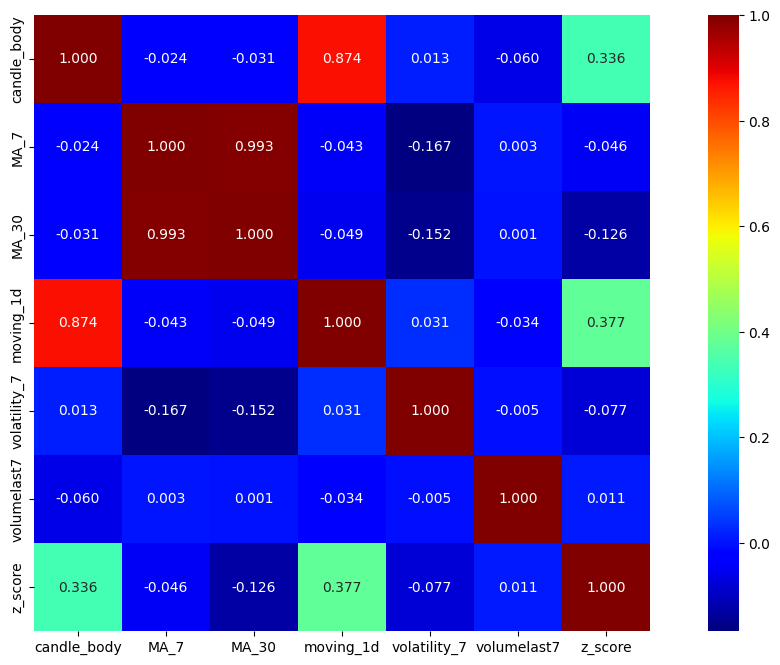

In [399]:
plt.figure(figsize=(15,8))
corr8=df1[['candle_body','MA_7','MA_30','moving_1d','volatility_7','volumelast7','z_score']].corr()
sns.heatmap(corr8,annot=True,square=True,cmap='jet',fmt='0.3f')
plt.show()

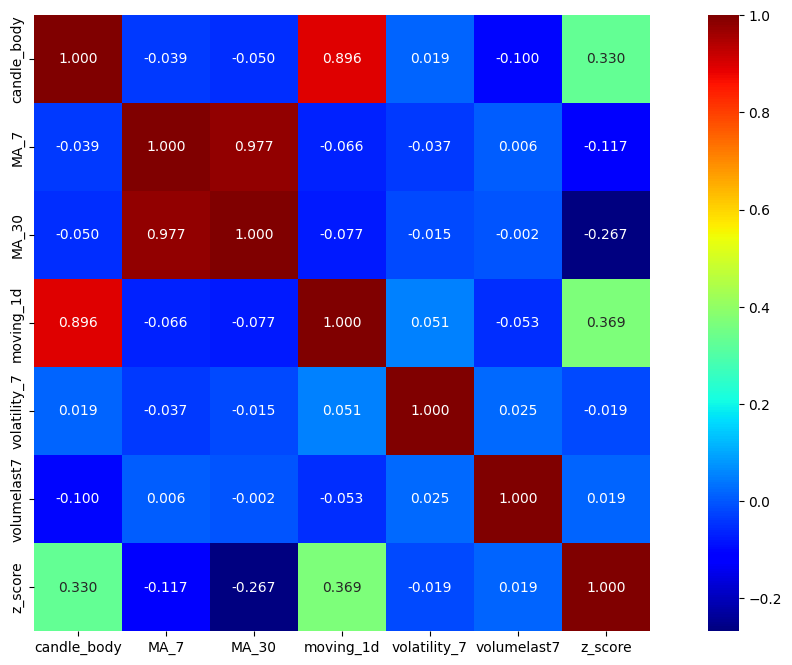

In [400]:
plt.figure(figsize=(15,8))
corr9=df2[['candle_body','MA_7','MA_30','moving_1d','volatility_7','volumelast7','z_score']].corr()
sns.heatmap(corr9,annot=True,square=True,cmap='jet',fmt='0.3f')
plt.show()

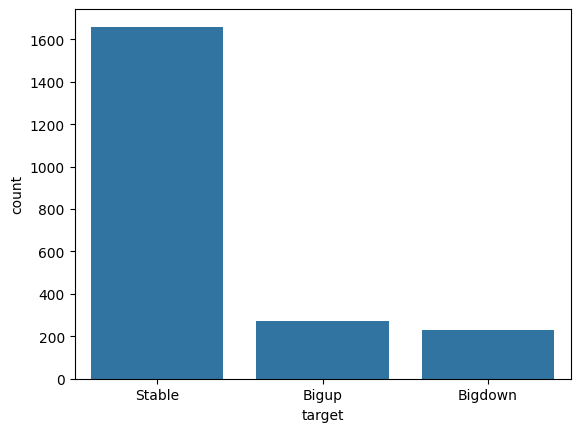

In [401]:
sns.countplot(x='target',data=df1)
plt.show()

In [402]:
df1['target'].value_counts()

target
Stable     1660
Bigup       271
Bigdown     229
Name: count, dtype: int64

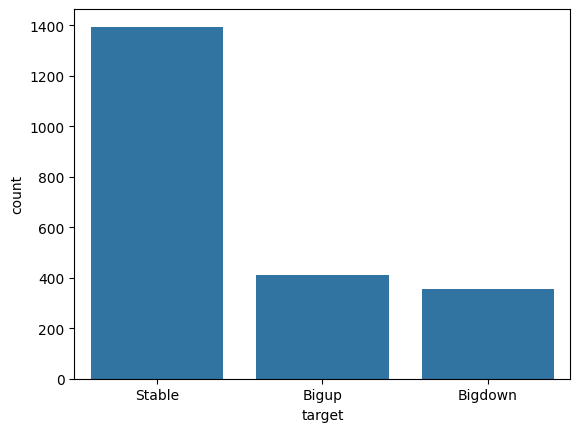

In [404]:
sns.countplot(x='target',data=df2)
plt.show()

In [406]:
df2['target'].value_counts()

target
Stable     1394
Bigup       409
Bigdown     357
Name: count, dtype: int64

In [413]:
combined=pd.concat([df1,df2],ignore_index=True)
combined.to_csv("eth_btc_data.csv",index=False)

In [414]:
df3=pd.read_csv("eth_btc_data.csv")

In [415]:
df3.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,target
0,2020-04-20,7121.40,7220.00,6751.0,6826.83,90149.491370,6.296124e+08,BTC,-294.57,469.00,6973.657143,6766.366000,-4.127520,4.021079,1.274637,0.157665,Stable
1,2020-04-21,6828.98,6940.00,6762.0,6841.37,60109.710808,4.118006e+08,BTC,12.39,178.00,6969.752857,6800.538667,0.212983,4.018091,0.865563,0.120445,Bigup
2,2020-04-22,6841.36,7156.38,6818.0,7125.14,61486.377334,4.312716e+08,BTC,283.78,338.38,7041.738571,6822.466333,4.147853,3.923088,0.885542,0.895536,Bigup
3,2020-04-23,7125.12,7738.00,7020.0,7482.39,102773.569561,7.563202e+08,BTC,357.27,718.00,7096.088571,6847.055333,5.013937,3.393093,1.551135,1.772948,Stable
4,2020-04-24,7483.96,7615.96,7388.0,7505.00,60182.119939,4.521181e+08,BTC,21.04,227.96,7164.295714,6874.641000,0.302176,3.308075,0.896607,1.675384,Stable
